In [1]:
import torch
import lightning as L

import time
import numpy as np
import matplotlib.pyplot as plt

from data import SLRDataModule, SyntheticLogReturnsDGP
from models import FinancialLSTM_MSE

from lightning.pytorch import Trainer
from lightning.pytorch.loggers import TensorBoardLogger
from lightning.pytorch.callbacks import (
    ModelCheckpoint, 
    LearningRateMonitor,
    TQDMProgressBar
)

# Config

In [2]:
torch.set_float32_matmul_precision('medium')

PATH = [
    'logs/test', # Save dir
    'v9',                  # Name
    'prediction_run_MSE=N_TRAIN=70_BATCH=1_EPOCH=16' # Version
]

/home/marko/Environments/python/fer/dipl/lib/python3.12/site-packages/torch/__init__.py:1617: UserWarning: Please use the new API settings to control TF32 behavior, such as torch.backends.cudnn.conv.fp32_precision = 'tf32' or torch.backends.cuda.matmul.fp32_precision = 'ieee'. Old settings, e.g, torch.backends.cuda.matmul.allow_tf32 = True, torch.backends.cudnn.allow_tf32 = True, allowTF32CuDNN() and allowTF32CuBLAS() will be deprecated after Pytorch 2.9. Please see https://pytorch.org/docs/main/notes/cuda.html#tensorfloat-32-tf32-on-ampere-and-later-devices (Triggered internally at /pytorch/aten/src/ATen/Context.cpp:80.)
  _C._set_float32_matmul_precision(precision)


# Data
data.py

In [3]:
dgp = SyntheticLogReturnsDGP(
    n_windows       = 300,
    n_stock         = 10,
    lookback_window = 60,
    target_window   = 20,
    prediction_task = True
)

dm  = SLRDataModule(
    dgp,
    n_dgp_train = 70,
    n_dgp_val   = 20,
    n_dgp_test  = 10,
    batch_size  = 1,
    seed        = None
)

# Model
models.py

In [4]:
model = FinancialLSTM_MSE(
    n_stocks        = 6,
    lookback_window = 60,
    target_window   = 20,
    input_size      = 3,
    hidden_size     = 64,
    num_layers      = 2,
    dropout         = 0.2,
    learning_rate   = 1e-4,
    lr_patience     = 4
)

model = torch.compile(model)

In [5]:
model

OptimizedModule(
  (_orig_mod): FinancialLSTM_MSE(
    (model): FinancialLSTM_Model(
      (lstm): LSTM(3, 64, num_layers=2, batch_first=True, dropout=0.2)
      (alpha_head): Linear(in_features=64, out_features=1, bias=True)
      (beta_head): Linear(in_features=64, out_features=1, bias=True)
    )
    (train_metric): MeanSquaredError()
    (val_metric): MeanSquaredError()
    (test_metrics): MetricCollection(
      (mse_alpha): MeanSquaredError()
      (mse_beta): MeanSquaredError()
      (mse_returns): MeanSquaredError()
    )
  )
)

## Trainer

#### Logger

In [6]:
tb_logger = TensorBoardLogger(
    save_dir          = PATH[0],
    name              = PATH[1],
    version           = PATH[2],
    default_hp_metric = True
)

#### Callbacks

In [7]:
callbacks = [
    ModelCheckpoint(
        dirpath=f"{PATH[0]}/{PATH[1]}/{PATH[2]}/checkpoints",
        filename="best_{epoch:02d}_{val_loss:.6f}",
        monitor="val_loss",
        mode="min",
        save_last=True,
        auto_insert_metric_name=True
    ),
    
    LearningRateMonitor(
        logging_interval="epoch",
        log_momentum=False
    ),

    TQDMProgressBar(refresh_rate=50)
]

#### Trainer

In [8]:
trainer = Trainer(
    max_epochs  = 16,
    logger      = tb_logger,
    callbacks   = callbacks,
    accelerator = 'auto',
    devices     = 'auto',
    gradient_clip_val    = 5.0,
    enable_progress_bar  = True,
    enable_model_summary = True
)

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores


## Train model

In [9]:
# ==================== Train the Model ====================
print("\n" + "="*50)
print("Starting Training...")
print("="*50 + "\n")

trainer.fit(model, datamodule=dm)

# ==================== Print Results ====================
print("\n" + "="*50)
print("Training Complete!")
print("="*50)
print(f"Best model path: {trainer.checkpoint_callback.best_model_path}")
print(f"Best validation loss: {trainer.checkpoint_callback.best_model_score:.6f}")
print("="*50 + "\n")


Starting Training...



LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]

  | Name         | Type                | Params | Mode 
-------------------------------------------------------------
0 | model        | FinancialLSTM_Model | 51.1 K | train
1 | train_metric | MeanSquaredError    | 0      | train
2 | val_metric   | MeanSquaredError    | 0      | train
3 | test_metrics | MetricCollection    | 0      | train
-------------------------------------------------------------
51.1 K    Trainable params
0         Non-trainable params
51.1 K    Total params
0.204     Total estimated model params size (MB)
10        Modules in train mode
0         Modules in eval mode


Sanity Checking: |                                                                                            …

Training: |                                                                                                   …

W0114 22:48:48.791000 1100289 torch/_dynamo/convert_frame.py:1358] [6/8] torch._dynamo hit config.recompile_limit (8)
W0114 22:48:48.791000 1100289 torch/_dynamo/convert_frame.py:1358] [6/8]    function: '_apply_to_collection_slow' (/home/marko/Environments/python/fer/dipl/lib/python3.12/site-packages/lightning_utilities/core/apply_func.py:86)
W0114 22:48:48.791000 1100289 torch/_dynamo/convert_frame.py:1358] [6/8]    last reason: 6/5: len(args) == 2                                           # return data  # lightning_utilities/core/apply_func.py:186 in _apply_to_collection_slow
W0114 22:48:48.791000 1100289 torch/_dynamo/convert_frame.py:1358] [6/8] To log all recompilation reasons, use TORCH_LOGS="recompiles".
W0114 22:48:48.791000 1100289 torch/_dynamo/convert_frame.py:1358] [6/8] To diagnose recompilation issues, see https://pytorch.org/docs/main/torch.compiler_troubleshooting.html
W0114 22:48:49.737000 1100289 torch/_dynamo/convert_frame.py:1358] [9/8] torch._dynamo hit config.rec

...

Validation: |                                                                                                 …

Validation: |                                                                                                 …

Validation: |                                                                                                 …

`Trainer.fit` stopped: `max_epochs=16` reached.



Training Complete!
Best model path: /home/marko/Workspace/FER/masters-thesis/logs/test/v9/prediction_run_MSE=N_TRAIN=70_BATCH=1_EPOCH=16/checkpoints/best_epoch=14_val_loss=0.000108.ckpt
Best validation loss: 0.000108



In [ ]:
trainer.test(model, datamodule=dm)

## Resume training

In [ ]:
# TODO Test if it works

model = FinancialLSTM_MGNLL(model_cfg)
#trainer = pl.Trainer()

# ==================== Train the Model ====================
print("\n" + "="*50)
print("Resuming Training...")
print("="*50 + "\n")

trainer.fit(model, train_loader, val_loader, ckpt_path='logs/financial_lstm/v8/prediction_run_MGNLL=N_TRAIN=70__BATCH=1_EPOCH=16/checkpoints/last.ckpt')

# ==================== Print Results ====================
print("\n" + "="*50)
print("Training Complete!")
print("="*50)
print(f"Best model path: {trainer.checkpoint_callback.best_model_path}")
print(f"Best validation loss: {trainer.checkpoint_callback.best_model_score:.6f}")
print("="*50 + "\n")

## Load model

# Benchmark

In [11]:
loss_function = torch.nn.MSELoss(reduction='mean')

model_summary = {
    'recon_loss': [],
    'alpha_loss': [],
    'beta_loss':[],
    'alpha': [],
    'beta': []
}

ols_summary = {
    'recon_loss': [],
    'alpha_loss': [],
    'beta_loss':[],
    'alpha': [],
    'beta': []
}

start_time = time.time()
print("Evauating model on test set...")

model.eval()
with torch.no_grad():
    for i, batch in enumerate(dm.test_dataloader()):
        # Unpack batch
        context = batch[0].squeeze(0)   # (n_stocks, lookback_window, features)
        target  = batch[1].squeeze(0)   # (n_stocks, target_window, features)
        
        # Extract components
        r_target        = target[:, :, 0]   # (n_stocks, target_window)
        r_market_target = target[:, :, 1]   # (n_stocks, target_window)
        alpha_gt        = target[:, 0, 2]   # (n_stocks)
        beta_gt         = target[:, 0, 3]   # (n_stocks)
        
        # Forward pass
        alpha_pred, beta_pred = model(context)  # (n_stocks, 1)
        r_pred = alpha_pred + beta_pred * r_market_target

        alpha_pred = alpha_pred.squeeze()
        beta_pred  = beta_pred.squeeze()
        
        model_summary['recon_loss'].append(loss_function(r_pred, r_target).item())
        model_summary['alpha_loss'].append(loss_function(alpha_pred, alpha_gt).item())
        model_summary['beta_loss'].append(loss_function(beta_pred, beta_gt).item())

        model_summary['alpha'].append(alpha_pred.detach())
        model_summary['beta'].append(beta_pred.detach())

        
        #OLS and OLS loss
        r_stocks = context[:, :, 0] # (n_stocks, lookback_window)
        r_market = context[0, :, 1] # (lookback_window)

        # Use OLS to calculate residual covariance matrix inverse
        X = r_market
        y = r_stocks
        
        # Add intercept
        intercept = torch.ones_like(X)
        X = torch.stack([intercept, X], dim=-1)

        # OLS formula
        OLS = torch.matmul(
            torch.linalg.pinv(torch.matmul(X.T, X)),
            torch.matmul(X.T, y.T)
        )
        
        OLS_alphas = OLS[0, :].unsqueeze(-1)
        OLS_betas  = OLS[1, :].unsqueeze(-1)
        
        r_pred = OLS_alphas + OLS_betas * r_market_target

        OLS_alphas = OLS_alphas.squeeze()
        OLS_betas = OLS_betas.squeeze()

        ols_summary['recon_loss'].append(loss_function(r_pred, r_target).item())
        ols_summary['alpha_loss'].append(loss_function(OLS_alphas, alpha_gt).item())
        ols_summary['beta_loss'].append(loss_function(OLS_betas, beta_gt).item())

        ols_summary['alpha'].append(OLS_alphas)
        ols_summary['beta'].append(OLS_betas)

"""
model_summary['alpha'] = torch.Tensor(model_summary['alpha']).reshape(datasets_cfg.n_dataset_test, datasets_cfg.n_windows, datasets_cfg.n_stock)
model_summary['beta'] = torch.Tensor(model_summary['beta']).reshape(datasets_cfg.n_dataset_test, datasets_cfg.n_windows, datasets_cfg.n_stock)

ols_summary['alpha'] = torch.Tensor(ols_summary['alpha']).reshape(datasets_cfg.n_dataset_test, datasets_cfg.n_windows, datasets_cfg.n_stock)
ols_summary['beta'] = torch.Tensor(ols_summary['beta']).reshape(datasets_cfg.n_dataset_test, datasets_cfg.n_windows, datasets_cfg.n_stock)
"""

print(f"Done! time = {time.time() - start_time:>7f} seconds")

Evauating model on test set...
Done! time = 2.405608 seconds


In [12]:
# Calculate test metrics for hp_metric
model_test_loss = np.mean(model_summary['recon_loss'])
ols_test_loss = np.mean(ols_summary['recon_loss'])

# Log hp_metric (model_test_loss)
tb_logger.log_hyperparams(
    params=model.hparams,
    metrics={'hp_metric': model_test_loss}
)

In [13]:
plt.figure(figsize=(10, 8))

plt.scatter(model_summary['recon_loss'], ols_summary['recon_loss'], marker='.')
plt.xlabel('Model Loss')
plt.ylabel('OLS Loss')

identity = np.linspace(min(ols_summary['recon_loss']), max(ols_summary['recon_loss']), 1000)
plt.plot(identity, identity, 'r--')

plt.title('Model vs OLS Reconstruction loss (MSE)')
plt.grid(alpha=0.5)

# Log to TensorBoard
tb_logger.experiment.add_figure('Model vs OLS Reconstruction loss (MSE)', plt.gcf())

In [14]:
plt.figure(figsize=(10, 8))

plt.hist(model_summary['recon_loss'], bins=100, alpha=0.6, label='Model')
plt.hist(ols_summary['recon_loss'], bins=100, alpha=0.6, label='OLS')

plt.axvline(model_test_loss, color='blue', linestyle='--', label=f'Avg Model Loss ({model_test_loss:.7f})')
plt.axvline(ols_test_loss, color='orange', linestyle='--', label=f'Avg OLS Loss    ({ols_test_loss:.7f})')

plt.title('Model vs OLS Reconstruction loss (MSE)')
plt.grid(alpha=0.5)
plt.legend()

# Log to TensorBoard
tb_logger.experiment.add_figure('Model vs OLS Reconstruction loss (MSE) Histogram', plt.gcf())

In [15]:
model_alpha_test_loss = np.mean(model_summary['alpha_loss'])
ols_alpha_test_loss = np.mean(ols_summary['alpha_loss'])

plt.figure(figsize=(10, 8))

plt.hist(model_summary['alpha_loss'], bins=100, alpha=0.6, label='Model')
plt.hist(ols_summary['alpha_loss'], bins=100, alpha=0.6, label='OLS')

plt.axvline(model_alpha_test_loss, color='blue', linestyle='--', label=f'Avg Model Loss ({model_alpha_test_loss:.7f})')
plt.axvline(ols_alpha_test_loss, color='orange', linestyle='--', label=f'Avg OLS Loss    ({ols_alpha_test_loss:.7f})')

plt.title('Model vs OLS Alpha loss (MSE)')
plt.grid(alpha=0.5)
plt.legend()

# Log to TensorBoard
tb_logger.experiment.add_figure('Model vs OLS Alpha loss (MSE)', plt.gcf())

In [16]:
model_beta_test_loss = np.mean(model_summary['beta_loss'])
ols_beta_test_loss = np.mean(ols_summary['beta_loss'])

plt.figure(figsize=(10, 8))

plt.hist(model_summary['beta_loss'], bins=100, alpha=0.6, label='Model')
plt.hist(ols_summary['beta_loss'], bins=100, alpha=0.6, label='OLS')

plt.axvline(model_beta_test_loss, color='blue', linestyle='--', label=f'Avg Model Loss ({model_beta_test_loss:.4f})')
plt.axvline(ols_beta_test_loss, color='orange', linestyle='--', label=f'Avg OLS Loss    ({ols_beta_test_loss:.4f})')

plt.title('Model vs OLS Beta loss (MSE)')
plt.grid(alpha=0.5)
plt.legend()

# Log to TensorBoard
tb_logger.experiment.add_figure('Model vs OLS Beta loss (MSE)', plt.gcf())

In [18]:
idxs = list(range(9))

model_summary['alpha'] = torch.stack(model_summary['alpha']).reshape(10, 300, 10)
ols_summary['alpha'] = torch.stack(ols_summary['alpha']).reshape(10, 300, 10)

model_summary['beta'] = torch.stack(model_summary['beta']).reshape(10, 300, 10)
ols_summary['beta'] = torch.stack(ols_summary['beta']).reshape(10, 300, 10)

In [20]:
gt = {
    'alpha': [],
    'beta': []
}

for i, batch in enumerate(dm.test_dataloader()):
    if i % 300 == 0:
        # Unpack batch
        target  = batch[1].squeeze(0)   # (n_stocks, target_window, features)
        
        alpha_gt = target[:, 0, 2]   # (n_stocks)
        beta_gt  = target[:, 0, 3]   # (n_stocks)

        gt['alpha'].append(alpha_gt)
        gt['beta'].append(beta_gt)

gt['alpha'] = torch.stack(gt['alpha']).reshape(10, 10)
gt['beta']  = torch.stack(gt['beta']).reshape(10, 10)

In [21]:
fig, axs = plt.subplots(3, 3, figsize=(10, 8), sharex=True, sharey=True)
fig.suptitle('Model vs OLS Alpha estimation')

axs = axs.flatten()

for ax, idx in zip(axs, idxs):
    alpha_gt    = gt['alpha'][idx, 0]
    model_alpha = model_summary['alpha'][idx, :, 0]
    ols_alpha   = ols_summary['alpha'][idx, :, 0]

    sample = np.arange(len(model_alpha))

    ax.set_title(f'DGP {idx}, Stock 0')
    ax.scatter(sample, model_alpha, label='Model', marker='.')
    ax.scatter(sample, ols_alpha, label='OLS', marker='.')
    ax.axhline(alpha_gt, color='magenta', linestyle='--', label='True alpha')

    ax.legend()
    ax.grid(alpha=0.5)

# Log to TensorBoard
tb_logger.experiment.add_figure('Model vs OLS Alpha estimation', fig)

In [22]:
fig, axs = plt.subplots(3, 3, figsize=(10, 8), sharex=True, sharey=True)
fig.suptitle('Model vs OLS Beta estimation')

axs = axs.flatten()

for ax, idx in zip(axs, idxs):
    beta_gt    = gt['beta'][idx, 0]
    model_beta = model_summary['beta'][idx, :, 0]
    ols_beta   = ols_summary['beta'][idx, :, 0]

    sample = np.arange(len(model_beta))

    ax.set_title(f'DGP {idx}, Stock 0')
    ax.scatter(sample, model_beta, label='Model', marker='.')
    ax.scatter(sample, ols_beta, label='OLS', marker='.')
    ax.axhline(beta_gt, color='magenta', linestyle='--', label='True beta')

    ax.legend()
    ax.grid(alpha=0.5)

# Log to TensorBoard
tb_logger.experiment.add_figure('Model vs OLS Beta estimation', fig)

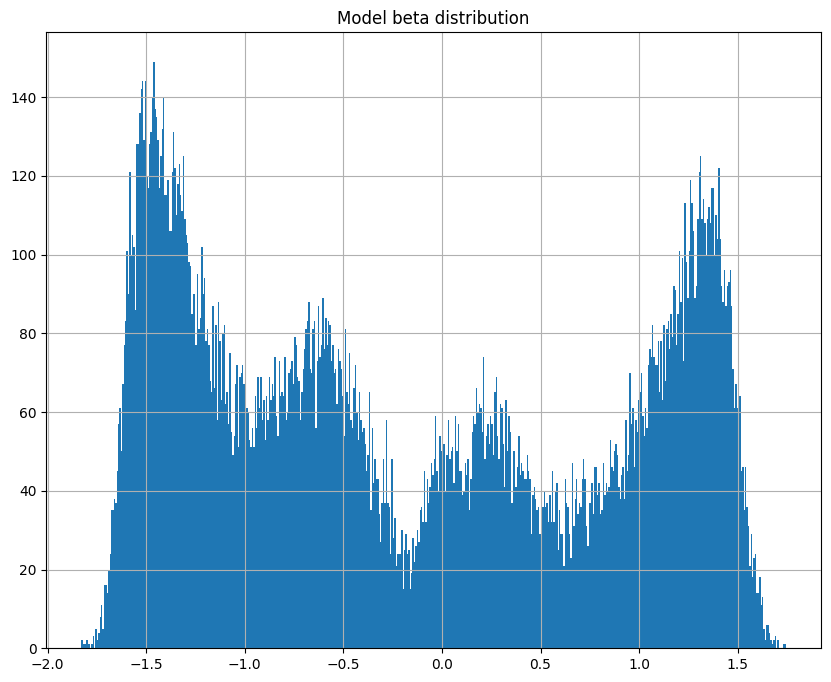

In [23]:
fig = plt.figure(figsize=(10, 8))
plt.hist(model_summary['beta'].flatten(), bins=500)
plt.title('Model beta distribution')

plt.grid()
#tb_logger.experiment.add_figure('Model Beta Distribution', fig)
plt.show()

In [25]:
n_stock=10
n_dataset_test=10
n_windows=300
true_betas = gt['beta']

idxs = list(range(n_stock * n_dataset_test))

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 8), sharex=True, sharey=True)
fig.suptitle('Ground Truth Beta vs Estimated Beta')

identity = np.linspace(true_betas.min(), true_betas.max(), 1000)

# Top subplot - Model
ax1.set_title('LSTM Model')
ax1.set_ylabel('Model Beta')
ax1.plot(identity, identity, color='magenta', linestyle='--')
ax1.grid()

# Bottom subplot - OLS
ax2.set_title('OLS')
ax2.set_xlabel('Ground Truth Beta')
ax2.set_ylabel('OLS Beta ')
ax2.plot(identity, identity, color='magenta', linestyle='--')
ax2.grid()

for idx in idxs:
    stock_idx   = idx % n_stock
    dataset_idx = idx // n_dataset_test
    
    true_beta  = true_betas[dataset_idx, stock_idx]
    model_beta = model_summary['beta'][dataset_idx, :, stock_idx]
    ols_beta   = ols_summary['beta'][dataset_idx, :, stock_idx]

    x = [true_beta] * n_windows

    ax1.scatter(x, model_beta, marker='.', alpha=0.1)
    ax2.scatter(x, ols_beta, marker='.', alpha=0.1)

tb_logger.experiment.add_figure('Ground Truth Beta vs Estimated Beta', fig)

In [27]:
tb_logger.save()